In [2]:
print("Welcome to Spaceship Titanic")

Welcome to Spaceship Titanic


In [3]:
import pandas as pd



In [23]:
train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")

In [5]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [24]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
train_df.HomePlanet.value_counts()

HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

In [264]:
train_df.Cabin.value_counts()

Cabin
G/734/S     8
F/1194/P    7
B/201/P     7
G/981/S     7
G/109/P     7
           ..
E/56/P      1
A/98/P      1
G/1499/S    1
G/1500/S    1
D/252/P     1
Name: count, Length: 6560, dtype: int64

In [265]:
train_df.Destination.value_counts()

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

In [25]:
train_df.set_index("PassengerId")
test_df.set_index("PassengerId")

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
PassengerId,,,,,,,,,,,,
0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore


In [26]:
import numpy as np

In [27]:
# Transported is destination Column
X_train = train_df.drop(columns=["Transported", "Name"])

X_test = train_df.drop(columns=["Name" ])


In [ ]:
def extract_group_from_passengerid(dataFrame):
    # Create Dataframe with column and split it while creating
    newframe = dataFrame["PassengerId"].str.split("_", n=1, expand=True)

    # Create a new column in per reference inserted Frame that is filled with indexed column from new frame (which holds separation)
    dataFrame["groupid"] = newframe[0]

extract_group_from_passengerid(X_train)

In [29]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,groupid
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004


In [30]:
X_train.set_index("PassengerId")

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,groupid
PassengerId,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004
...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,9276
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,9278
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,9279


In [271]:
# Defining categorical and numerical columns. The Preprocessing pipelines differ in imputing and the steps after imputing

num_columns = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
cat_columns = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

from sklearn.pipeline import Pipeline


In [272]:
# Numerical Pipeline
# We will impute missing values and after that we will scale 0 to 1
# for this data we will try mean

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('num_imputer', SimpleImputer(strategy="mean"))
    , ('num_scaler', StandardScaler())
])


In [273]:

# Categorical Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Stategy 1
# Ordinal Endoce Categorical Values (0 to n) --> Only useful when the column data has an ordinal or range based nature
# Here we use it as a first step to convert to numerical and then impute with a numerical stategy
# Then use OneHotEncoder for the final form

# cat_pipeline = Pipeline([
#     ("cat_ordinal", OrdinalEncoder())
#     , ("cat_imputer", SimpleImputer(strategy="most_frequent"))
#     , ("cat_onehot", OneHotEncoder(sparse_output=False))
# ])

# Strategy 2
# most_frequent with OneHotEncoder 

cat_pipeline = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="most_frequent"))
    , ("cat_encoder", OneHotEncoder())
])

In [274]:
# declare a column transformer (actually instanciate)
from sklearn.compose import ColumnTransformer

column_transformer = ColumnTransformer([
    ("num_col_transform", num_pipeline, num_columns)
    , ("cat_col_transform", cat_pipeline, cat_columns)
])

In [275]:
X_train_prepared = column_transformer.fit_transform(X_train)

In [276]:
# Output is a sparse Matrix

# This is the third record
X_train_prepared[[2]]

array([[ 2.03456565, -0.27540886,  1.95561575, -0.29081703,  5.69428913,
        -0.22578201,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ]])

In [277]:
X_train_prepared

array([[ 0.70943692, -0.34058987, -0.28731404, ...,  1.        ,
         1.        ,  0.        ],
       [-0.33671733, -0.1753636 , -0.28166908, ...,  1.        ,
         1.        ,  0.        ],
       [ 2.03456565, -0.27540886,  1.95561575, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-0.1972301 , -0.34058987, -0.28731404, ...,  1.        ,
         1.        ,  0.        ],
       [ 0.2212316 , -0.34058987,  0.37063712, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.05815501, -0.14959437,  2.65308161, ...,  1.        ,
         1.        ,  0.        ]], shape=(8693, 16))

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

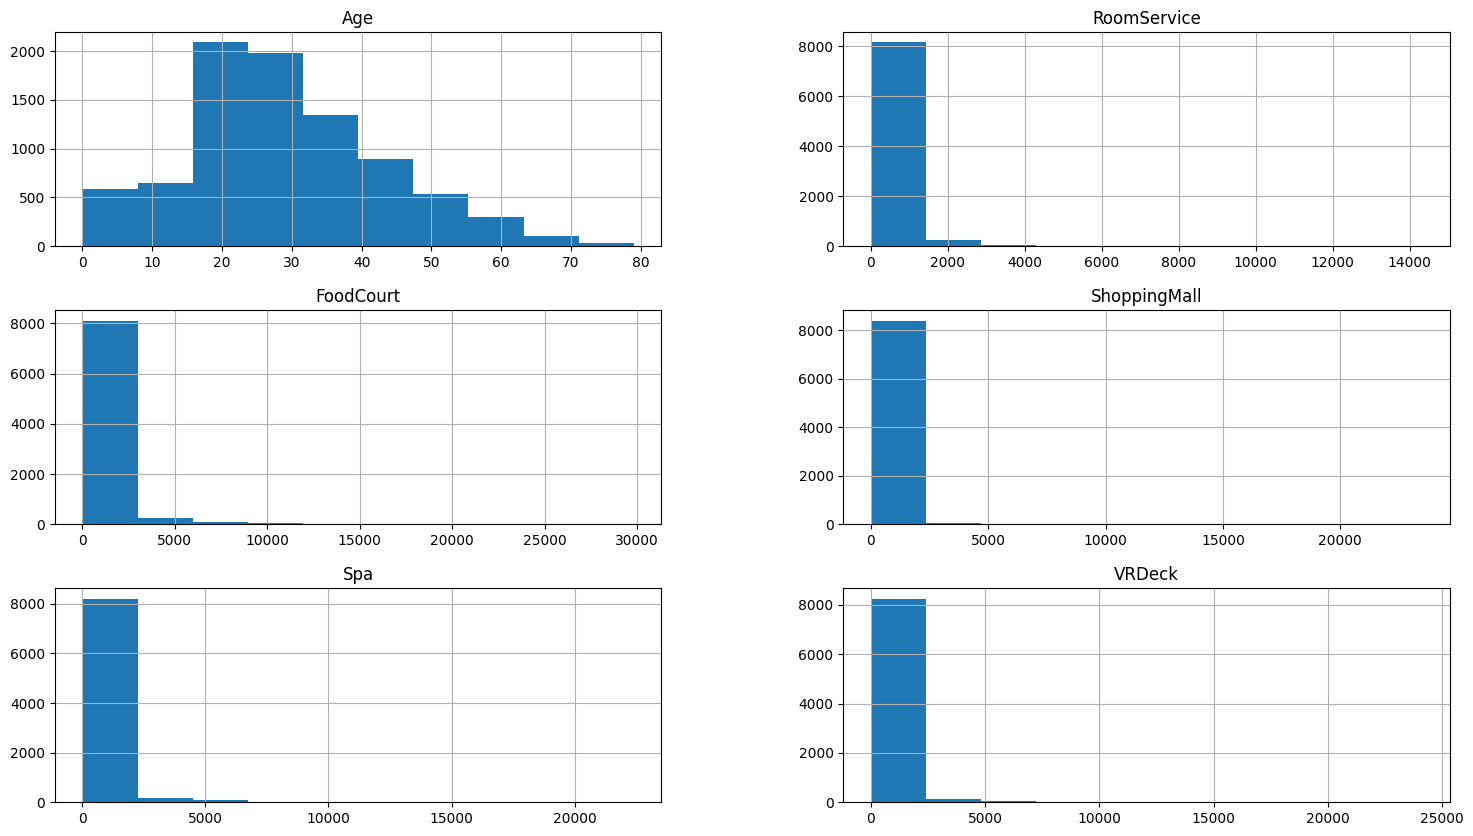

In [278]:
import matplotlib.pyplot as plt
num_col_df = X_train.select_dtypes(include="number")
num_col_df.hist(figsize=(18,10), bins=10)

In [ ]:
# Ready to train with this simplified Data
# But i think we should take a look at the Cabin in a future iteration
# Cabin --> The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
# Maybe we should also separate the passenger id because the first element is the traveling group. So whe can still use the combination as index but maybe the group has an influence (Family or something else)
# returns a Series!!! not a Data frame

y_train = train_df["Transported"].copy()

In [280]:
y_train

0       False
1        True
2       False
3       False
4        True
        ...  
8688    False
8689    False
8690     True
8691    False
8692     True
Name: Transported, Length: 8693, dtype: bool

In [326]:
y_train.mean()

np.float64(0.5036236051995858)

In [281]:
# 8693 so data is complete. But i convert tu numerical

y_train_numerical = y_train.map({True: 1, False: 0})

In [282]:
y_train_numerical

0       0
1       1
2       0
3       0
4       1
       ..
8688    0
8689    0
8690    1
8691    0
8692    1
Name: Transported, Length: 8693, dtype: int64

In [283]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dec_tree_clf = DecisionTreeClassifier(random_state=42)

In [284]:
# Scoring without scoring description --> The estimators default criteria is used
dec_tree_val = cross_val_score(dec_tree_clf, X_train_prepared, y_train, cv=5)

In [285]:
dec_tree_val.mean()


np.float64(0.735993994141045)

In [286]:
from sklearn.ensemble import RandomForestClassifier

rand_tree_clf = RandomForestClassifier(n_estimators=500, random_state=42)

In [287]:
rand_tree_val = cross_val_score(rand_tree_clf, X_train_prepared, y_train_numerical, cv=5)

In [288]:
rand_tree_val.mean()

np.float64(0.7822406300725719)

In [289]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")

In [290]:
svm_val = cross_val_score(svm_clf, X_train_prepared, y_train, cv=5)

In [291]:
svm_val.mean()

np.float64(0.7889126523384535)

In [292]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(random_state=42, hidden_layer_sizes=(50, 50, 50), activation="relu")

In [ ]:
mlp_val = cross_val_score(mlp_clf, X_train_prepared, y_train_numerical, cv=5)

c:\Users\Torst\Documents\GitHub\MachineLearning-Collection\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Torst\Documents\GitHub\MachineLearning-Collection\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Torst\Documents\GitHub\MachineLearning-Collection\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Torst\Documents\GitHub\MachineLearning-Collection\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maxim

In [294]:
mlp_val.mean()

np.float64(0.7847719447773314)

In [295]:
from sklearn.neighbors import KNeighborsClassifier

neighbor_clf = KNeighborsClassifier(n_neighbors= 4, weights='distance')

In [296]:
neighbor_score = cross_val_score(neighbor_clf, X_train_prepared, y_train, cv=10)

In [297]:
neighbor_score.mean()

np.float64(0.7350700369032975)

In [306]:
# Param Grid for best estimator in first test

param_grid = {
    "min_samples_split": range(2, 5)
    , "min_samples_leaf": [1, 2, 4]
    , "n_estimators": [200, 500, 1000]
}



In [307]:
rand_clf_base = RandomForestClassifier(random_state=42)
grid_search_rand_tree = GridSearchCV(rand_clf_base, param_grid=param_grid, scoring="accuracy", cv=5)
grid_search_rand_tree.fit(X_train_prepared, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'min_samples_leaf': [1, 2, ...], 'min_samples_split': range(2, 5), 'n_estimators': [200, 500, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [308]:
grid_search_rand_tree.best_params_

{'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}

In [309]:
grid_search_rand_tree.best_score_

np.float64(0.7955850054691961)

In [312]:
#y_pred
X_test = test_df.drop(columns=["Name", "Cabin"])
X_test.set_index("PassengerId")

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
PassengerId,,,,,,,,,,
0013_01,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0
0018_01,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0
0019_01,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0
0021_01,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0
0023_01,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0
9269_01,Earth,False,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0
9271_01,Mars,True,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0


In [314]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Destination   4185 non-null   object 
 4   Age           4186 non-null   float64
 5   VIP           4184 non-null   object 
 6   RoomService   4195 non-null   float64
 7   FoodCourt     4171 non-null   float64
 8   ShoppingMall  4179 non-null   float64
 9   Spa           4176 non-null   float64
 10  VRDeck        4197 non-null   float64
dtypes: float64(6), object(5)
memory usage: 367.7+ KB


In [ ]:
# Also perform imputing and scaling on test dataset
X_test_prepared = column_transformer.fit_transform(X_test)

In [316]:
y_test = grid_search_rand_tree.best_estimator_.predict(X_test_prepared)

In [ ]:
# y test was not numeric
y_test

array([ True, False,  True, ...,  True,  True,  True], shape=(4277,))

In [318]:
X_test["PassengerId"]

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: object

In [324]:
result_df = X_test[["PassengerId"]]

In [327]:
result_df

,PassengerId
0,0013_01
1,0018_01
2,0019_01
3,0021_01
4,0023_01
...,...
4272,9266_02
4273,9269_01
4274,9271_01
4275,9273_01


In [330]:
pred_as_list = y_test.tolist()

In [331]:
pred_as_list

[True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 True,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 False,
 False,
 True,
 True,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 True,
 False,
 True,
 True,
 True,
 False,
 True,
 False,
 False,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 False,
 True,
 False,
 True,
 Tr

In [332]:
result_df["Transported"] = pred_as_list

C:\Users\Torst\AppData\Local\Temp\ipykernel_67616\2161858814.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df["Transported"] = pred_as_list


In [333]:
result_df

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [335]:
result_df.to_csv("./data/submission.csv", index=False)

In [ ]:
# Uploaded Base
# Now exploring Base